<a href="https://www.kaggle.com/code/mumerfarooqbajwa/polynomial-linear-regression?scriptVersionId=341378767" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/larsen0966/student-performance-data-set/student-por.csv
/kaggle/input/datasets/mexwell/regression-datasets/polynomial_regression.csv
/kaggle/input/datasets/mexwell/regression-datasets/multiple_linear_regression.csv
/kaggle/input/datasets/mexwell/regression-datasets/linear_regression.csv


# **Single Feature Polynomial Linear Regression**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mexwell/regression-datasets")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mexwell/regression-datasets


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/kaggle/input/datasets/mexwell/regression-datasets/polynomial_regression.csv")
df.head(4)

,Unnamed: 0,X,Y
0,0,3.745401,9.697527
1,1,9.507143,50.945226
2,2,7.319939,30.691604
3,3,5.986585,18.765792


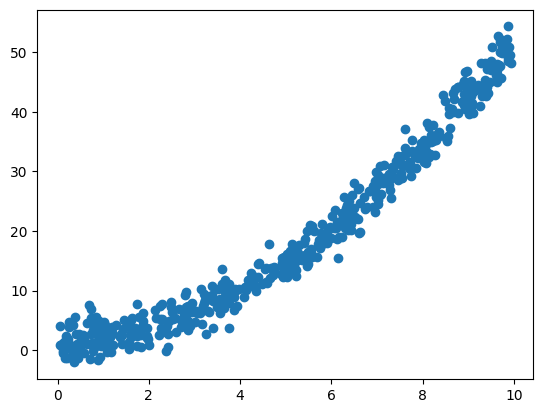

In [5]:
plt.scatter(df.iloc[:,-2], df.iloc[:,-1])

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,-2], df.iloc[:,-1], test_size=0.25, random_state =42)

In [7]:
X_train.values.reshape(-1,1)

array([[3.93097725],
       [3.28664545],
       [8.98554189],
       [8.18014766],
       [2.4773099 ],
       [1.70524124],
       [8.0812038 ],
       [0.12154475],
       [8.10113395],
       [9.62447295],
       [1.95982862],
       [9.00418057],
       [4.56069984],
       [5.24756432],
       [7.40768618],
       [1.40924225],
       [0.05061584],
       [5.23097844],
       [7.7096718 ],
       [3.16922005],
       [6.97015741],
       [3.66361843],
       [0.93674768],
       [9.9005385 ],
       [4.41530501],
       [1.5599452 ],
       [8.03672077],
       [6.62522284],
       [3.04242243],
       [7.46044879],
       [5.85775581],
       [5.98658484],
       [6.49632899],
       [8.95523228],
       [3.8867729 ],
       [2.89751453],
       [1.56437043],
       [3.50915013],
       [0.46450413],
       [8.21860059],
       [9.69878827],
       [1.99673782],
       [8.66176146],
       [9.06354385],
       [2.28798165],
       [0.97672114],
       [7.61619615],
       [8.902

In [8]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train.values.reshape(-1,1), y_train.values)


LinearRegression()

In [9]:
from sklearn.metrics import r2_score
predicted_y = reg.predict(X_test.values.reshape(-1,1))

r2_score (y_test, predicted_y)

0.913388252741439

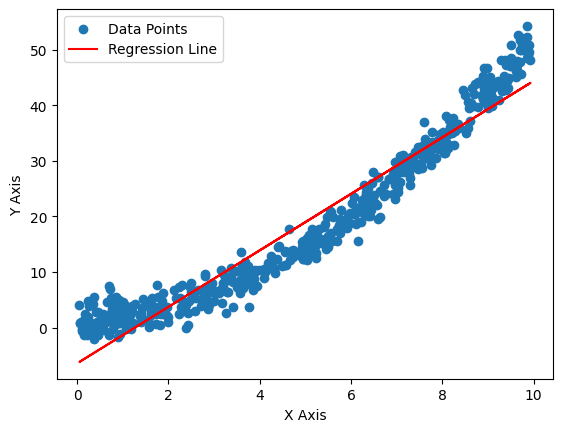

In [10]:
plt.scatter(df.iloc[:,-2], df.iloc[:,-1],label="Data Points")
plt.plot (df.iloc[:,-2], reg.predict(df.iloc[:,-2].values.reshape(-1,1)), color='red', label="Regression Line" )
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.legend()

In [11]:
from sklearn.preprocessing import  PolynomialFeatures

poly = PolynomialFeatures(degree=2) # 2 is optimal degree for this dataset

X_train_poly = poly.fit_transform(X_train.values.reshape(-1,1))
X_test_poly = poly.transform (X_test.values.reshape(-1,1))

In [12]:
reg.fit(X_train_poly, y_train)

LinearRegression()

In [13]:
predicted_y= reg.predict(X_test_poly)

r2_score(predicted_y, y_test)

0.9801858475037393

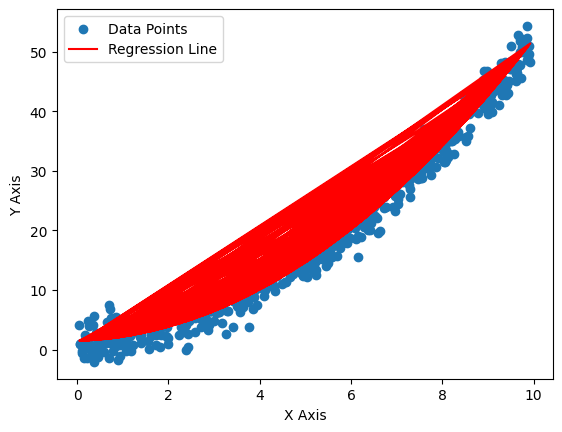

In [14]:
plt.scatter(df.iloc[:,-2], df.iloc[:,-1], label="Data Points")
plt.plot (df.iloc[:,-2], reg.predict(poly.transform(df.iloc[:,-2].values.reshape(-1,1))), color='red', label="Regression Line" )
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.legend()

# **Multi Feature Polynomial Linear Regression**

In [15]:
x1 = 267*np.random.rand(100,1)-3
x2 = 314*np.random.rand(100,1)-18

y = 0.7*x1 + 1.2 * x2 ** 2 + 0.35 * x1*x2 + 3.2*x1 +5*np.random.rand(100,1)

In [16]:
import plotly.express as px

df = pd.DataFrame({
    "x1":x1.ravel(),
    "x2":x2.ravel(),
    "y":y.ravel()
})


fig = px.scatter_3d(
    df,
    x="x1",
    y="x2",
    z= "y",
    color="y",
    opacity=0.8
)
fig.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.2, random_state=42)

# With Linear Regression

In [18]:
reg= LinearRegression()
reg.fit(X_train, y_train)
predicted_y = reg.predict(X_test)
r2_score(y_test, predicted_y)

0.9278525602125562

# With Polynomial Regression

In [19]:
poly=PolynomialFeatures(degree=2)
poly_X_train= poly.fit_transform(X_train)
poly_X_test = poly.transform (X_test)

poly_X_train

array([[ 1.00000000e+00,  1.22751627e+02,  1.96603525e+02,
         1.50679619e+04,  2.41334026e+04,  3.86529462e+04],
       [ 1.00000000e+00,  1.98520048e+02,  2.44379461e+02,
         3.94102096e+04,  4.85142223e+04,  5.97213208e+04],
       [ 1.00000000e+00,  2.01360023e+02,  2.85381581e+02,
         4.05458589e+04,  5.74644418e+04,  8.14426468e+04],
       [ 1.00000000e+00,  2.16568413e+02,  7.62430961e+00,
         4.69018775e+04,  1.65118463e+03,  5.81300970e+01],
       [ 1.00000000e+00,  1.94460610e+02,  1.61760504e+01,
         3.78149290e+04,  3.14560464e+03,  2.61664607e+02],
       [ 1.00000000e+00,  1.37224913e+02,  7.85785582e+01,
         1.88306768e+04,  1.07829358e+04,  6.17458982e+03],
       [ 1.00000000e+00, -1.07332667e+00,  2.73293476e+02,
         1.15203014e+00, -2.93333177e+02,  7.46893240e+04],
       [ 1.00000000e+00,  2.04883241e+02,  1.28987629e+01,
         4.19771425e+04,  2.64274036e+03,  1.66378085e+02],
       [ 1.00000000e+00,  1.58792828e+02,  1.629

In [20]:
reg= LinearRegression()

reg.fit(poly_X_train, y_train)
y_predicted = reg.predict(poly_X_test)

r2_score(y_predicted , y_test)

0.9999999979975297

In [21]:
X = df.iloc[:,:-1]

poly_X = poly.transform(X)
poly_X

array([[ 1.00000000e+00,  1.18332674e+02,  1.71464364e+02,
         1.40026218e+04,  2.02898368e+04,  2.94000283e+04],
       [ 1.00000000e+00,  1.86063415e+01,  2.57964719e+02,
         3.46195945e+02,  4.79977967e+03,  6.65457964e+04],
       [ 1.00000000e+00,  4.89417224e+01,  2.95738373e+01,
         2.39529219e+03,  1.44739453e+03,  8.74611850e+02],
       [ 1.00000000e+00,  1.80920774e+02,  1.07711144e+02,
         3.27323264e+04,  1.94871836e+04,  1.16016906e+04],
       [ 1.00000000e+00,  1.84172310e+02, -1.75660601e+01,
         3.39194396e+04, -3.23518186e+03,  3.08566468e+02],
       [ 1.00000000e+00,  1.00202904e+02,  6.51317389e+00,
         1.00406220e+04,  6.52638940e+02,  4.24214342e+01],
       [ 1.00000000e+00,  7.56858667e+01,  8.27999024e+01,
         5.72835041e+03,  6.26678237e+03,  6.85582384e+03],
       [ 1.00000000e+00,  1.62675911e+02,  6.87425307e+01,
         2.64634519e+04,  1.11827538e+04,  4.72553553e+03],
       [ 1.00000000e+00,  1.59265823e+02,  1.394

In [22]:
import plotly.graph_objects as go

# 1. Your original scatter plot
fig = px.scatter_3d(df, x="x1", y="x2", z="y", color="y", opacity=0.8)

# 2. Calculate predictions as a flat 1D array
y_pred = reg.predict(poly_X).ravel()

# 3. Add the regression surface using Mesh3d for 1D arrays
fig.add_trace(
    go.Mesh3d(
        x=df["x1"],  # 1D array/Series
        y=df["x2"],  # 1D array/Series
        z=y_pred,  # 1D array of predicted targets
        color="blue",  # Sets a clean solid blue surface
        opacity=0.4,  # Semi-transparent so you can see points underneath
        name="Regression Surface",
        showlegend=True,
    )
)

fig.show()
